# Task 4 — Investment Strategies


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

def draw_heatmap(ax, data_df, annot_df=None, cmap="RdYlGn", center=0,
                 vmin=None, vmax=None, title="", cbar_label=""):
    mat = data_df.values.astype(float)
    absmax = np.nanmax(np.abs(mat - center)) or 1
    im = ax.imshow(mat, cmap=cmap, aspect="auto",
                   vmin=vmin if vmin is not None else center - absmax,
                   vmax=vmax if vmax is not None else center + absmax)
    ax.set_xticks(range(len(data_df.columns)))
    ax.set_xticklabels(data_df.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(data_df.index)))
    ax.set_yticklabels(data_df.index, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = annot_df.iloc[i, j] if annot_df is not None else mat[i, j]
            txt = val if isinstance(val, str) else (f"{val:.2f}" if pd.notna(val) else "")
            ax.text(j, i, txt, ha="center", va="center", fontsize=8)
    cb = plt.colorbar(im, ax=ax, shrink=0.8)
    if cbar_label:
        cb.set_label(cbar_label, fontsize=8)
    if title:
        ax.set_title(title, fontsize=9)

DATA_PATH = "/Users/vilgotparsmo/Documents/GitHub/TMS088/Data/spiff_data-2.csv"  # adjust path if needed
RF_ANNUAL = 0.03
ANN       = 365
RF_DAILY  = RF_ANNUAL / ANN

prices_raw = pd.read_csv(DATA_PATH, index_col=0)
prices_raw.index = prices_raw.index.astype(int)
prices_raw.index.name = "day"
prices_raw[prices_raw == 1000] = np.nan

DATA_START = 1500
DATA_END   = 5256
IS_FRAC    = 0.70

prices_clean = prices_raw.iloc[DATA_START:DATA_END].copy().ffill()
assert prices_clean.isna().sum().sum() == 0

n_clean    = len(prices_clean)
is_size    = int(n_clean * IS_FRAC)
prices_is  = prices_clean.iloc[:is_size]
prices_oos = prices_clean.iloc[is_size:]
split_day  = prices_is.index[-1]

output       = Path(".")
asset_colors = dict(zip(prices_is.columns, plt.cm.tab10.colors))

print(f"IS  : day {prices_is.index[0]} - {split_day}  ({len(prices_is)} obs)")
print(f"OoS : day {prices_oos.index[0]} - {prices_oos.index[-1]}  ({len(prices_oos)} obs)")


IS  : day 1500 - 4128  (2629 obs)
OoS : day 4129 - 5255  (1127 obs)


In [2]:
def apply_signal(signal, prices):
    log_ret   = np.log(prices).diff()
    strat_ret = signal * log_ret
    return {"signals": signal, "returns": strat_ret, "cumulative": strat_ret.cumsum()}


In [3]:
def ma_crossover_signal(prices, fast, slow):
    return (prices.rolling(fast).mean() > prices.rolling(slow).mean()).astype(float).shift(1)

def buy_and_hold_signal(prices):
    return pd.DataFrame(1.0, index=prices.index, columns=prices.columns)

def pairs_signal(prices, asset1, asset2, window=60, entry_z=1.5, exit_z=0.5):
    spread = np.log(prices[asset1]) - np.log(prices[asset2])
    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
    raw1, raw2 = pd.Series(np.nan, index=prices.index), pd.Series(np.nan, index=prices.index)
    raw1[z.lt(-entry_z)] = 1.0; raw2[z.lt(-entry_z)] = 0.0
    raw1[z.gt(entry_z)]  = 0.0; raw2[z.gt(entry_z)]  = 1.0
    raw1[z.abs().lt(exit_z)] = 0.0; raw2[z.abs().lt(exit_z)] = 0.0
    out = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    out[asset1] = raw1.ffill().fillna(0.0)
    out[asset2] = raw2.ffill().fillna(0.0)
    return out.shift(1)

def pairs_ls_signal(prices, asset1, asset2, window=60, entry_z=1.5, exit_z=0.5):
    spread = np.log(prices[asset1]) - np.log(prices[asset2])
    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
    raw1, raw2 = pd.Series(np.nan, index=prices.index), pd.Series(np.nan, index=prices.index)
    raw1[z.lt(-entry_z)] =  1.0; raw2[z.lt(-entry_z)] = -1.0
    raw1[z.gt(entry_z)]  = -1.0; raw2[z.gt(entry_z)]  =  1.0
    raw1[z.abs().lt(exit_z)] = 0.0; raw2[z.abs().lt(exit_z)] = 0.0
    out = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    out[asset1] = raw1.ffill().fillna(0.0)
    out[asset2] = raw2.ffill().fillna(0.0)
    return out.shift(1)

def gw_signal(prices, window=60, entry_z=1.5, exit_z=0.5):
    return pairs_signal(prices, "gurkor", "water", window, entry_z, exit_z)
def gusl_signal(prices, window=60, entry_z=1.5, exit_z=0.5):
    return pairs_signal(prices, "guitars", "slingshots", window, entry_z, exit_z)
def gw_ls_signal(prices, window=60, entry_z=1.5, exit_z=0.5):
    return pairs_ls_signal(prices, "gurkor", "water", window, entry_z, exit_z)
def gusl_ls_signal(prices, window=60, entry_z=1.5, exit_z=0.5):
    return pairs_ls_signal(prices, "guitars", "slingshots", window, entry_z, exit_z)


In [4]:
MA_PARAM_GRID = [
    {"fast": f, "slow": s}
    for f in [2, 5, 10, 20, 30]
    for s in [20, 40, 60, 80, 120, 150, 200, 252]
    if f < s
]
PAIRS_PARAM_GRID = [
    {"window": w, "entry_z": e, "exit_z": 0.5}
    for w in [2, 5, 10, 30, 60]
    for e in [0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 1.5, 2.0]
]

def grid_search(prices_ref, signal_fn, param_grid, ann=365):
    rows = []
    for params in param_grid:
        sig  = signal_fn(prices_ref, **params)
        port = apply_signal(sig, prices_ref)["returns"].mean(axis=1).dropna()
        vol  = port.std() * np.sqrt(ann)
        sr   = port.mean() * ann / vol if vol > 0 else np.nan
        rows.append({**params, "sharpe": sr})
    return pd.DataFrame(rows)

def per_asset_grid_search(prices_ref, signal_fn, param_grid, ann=365):
    """Returns best params per asset, preserving original types from param_grid."""
    best = {}
    for col in prices_ref.columns:
        rows = []
        for params in param_grid:
            sig = signal_fn(prices_ref, **params)
            ret = (sig[col] * np.log(prices_ref[col]).diff()).dropna()
            vol = ret.std() * np.sqrt(ann)
            sr  = ret.mean() * ann / vol if vol > 0 and not (ret == 0).all() else np.nan
            rows.append({**params, "sharpe": sr})
        df      = pd.DataFrame(rows)
        best_idx = df["sharpe"].idxmax()
        # Use the original param dict directly to preserve types (int, float, etc.)
        best[col] = param_grid[best_idx]
    return best

def build_per_asset_signal(prices, signal_fn, best_params):
    return pd.concat([signal_fn(prices, **best_params[col])[[col]]
                      for col in prices.columns], axis=1)


In [5]:
def backtest_metrics(strat_ret, bh_ret=None, ann=365):
    sr = strat_ret.dropna()
    if sr.empty:
        return {}
    cum     = sr.cumsum()
    ann_ret = sr.mean() * ann
    ann_vol = sr.std() * np.sqrt(ann)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    equity  = np.exp(cum)
    n_years = len(sr) / ann
    cagr    = (equity.iloc[-1] ** (1 / n_years) - 1) * 100 if n_years > 0 else np.nan
    max_dd  = (equity / equity.cummax() - 1).min() * 100
    active  = (sr != 0).astype(int)
    n_tr    = int(((active == 1) & (active.shift(1, fill_value=0) == 0)).sum())
    avg_h   = float(active.sum() / n_tr) if n_tr > 0 else np.nan
    tpy     = float(n_tr / (len(sr) / ann)) if n_tr > 0 else np.nan
    out = {
        "ann_return": round(ann_ret * 100, 2),
        "cagr":       round(cagr, 2),
        "excess_rf":  round((ann_ret - RF_ANNUAL) * 100, 2),
        "ann_vol":    round(ann_vol * 100, 2),
        "sharpe":     round(sharpe, 3) if not np.isnan(sharpe) else np.nan,
        "max_dd":     round(max_dd, 2),
        "trades_yr":  round(tpy, 1) if tpy and not np.isnan(tpy) else np.nan,
        "hold_days":  round(avg_h, 1) if avg_h and not np.isnan(avg_h) else np.nan,
    }
    if bh_ret is not None:
        bh   = bh_ret.dropna()
        bh_v = bh.std() * np.sqrt(ann)
        out["bh_sharpe"] = round(bh.mean() * ann / bh_v, 3) if bh_v > 0 else np.nan
        out["excess_bh"] = round((ann_ret - bh.mean() * ann) * 100, 2)
    return out


In [6]:
WF_FOLDS    = 21
WF_IS_SIZE  = 500
WF_OOS_SIZE = 100

def walk_forward(prices, signal_fn, param_grid, n_folds=WF_FOLDS,
                 is_size=WF_IS_SIZE, oos_size=WF_OOS_SIZE, ann=365, per_asset=False):
    oos_chunks, fold_rows, param_rows = [], [], []
    orig_types = {k: type(v) for k, v in param_grid[0].items()} if param_grid else {}
    for fold in range(n_folds):
        is_start  = fold * oos_size
        is_end    = is_start + is_size
        oos_start = is_end
        oos_end   = oos_start + oos_size
        if oos_end > len(prices):
            break
        p_is     = prices.iloc[is_start:is_end]
        p_oos    = prices.iloc[oos_start:oos_end]
        combined = prices.iloc[is_start:oos_end]
        if per_asset:
            best_p = per_asset_grid_search(p_is, signal_fn, param_grid, ann=ann)
            sig    = build_per_asset_signal(combined, signal_fn, best_p)
            fold_rows.append({"fold": fold+1, "OoS start": p_oos.index[0], "OoS end": p_oos.index[-1]})
            param_rows.append({"fold": fold+1})
        elif param_grid:
            g      = grid_search(p_is, signal_fn, param_grid, ann=ann)
            best_r = g.loc[g["sharpe"].idxmax()]
            best_p = {k: orig_types[k](best_r[k]) for k in orig_types}
            sig    = signal_fn(combined, **best_p)
            fold_rows.append({"fold": fold+1, "OoS start": p_oos.index[0],
                               "OoS end": p_oos.index[-1], "IS Sharpe": round(float(best_r["sharpe"]),3),
                               **{k: best_p[k] for k in orig_types}})
            param_rows.append({"fold": fold+1, **best_p})
        else:
            sig = signal_fn(combined)
            fold_rows.append({"fold": fold+1, "OoS start": p_oos.index[0], "OoS end": p_oos.index[-1]})
            param_rows.append({"fold": fold+1})
        oos_chunks.append(apply_signal(sig, combined)["returns"].loc[p_oos.index])
    return pd.concat(oos_chunks), pd.DataFrame(fold_rows), pd.DataFrame(param_rows)

print("Running walk-forward for all strategies...")
wf_ma,      wf_sum_ma,      wf_par_ma      = walk_forward(prices_is, ma_crossover_signal, MA_PARAM_GRID, per_asset=True)
wf_gw,      wf_sum_gw,      wf_par_gw      = walk_forward(prices_is, gw_signal,           PAIRS_PARAM_GRID)
wf_gusl,    wf_sum_gusl,    wf_par_gusl    = walk_forward(prices_is, gusl_signal,         PAIRS_PARAM_GRID)
wf_gw_ls,   wf_sum_gw_ls,   wf_par_gw_ls   = walk_forward(prices_is, gw_ls_signal,        PAIRS_PARAM_GRID)
wf_gusl_ls, wf_sum_gusl_ls, wf_par_gusl_ls = walk_forward(prices_is, gusl_ls_signal,      PAIRS_PARAM_GRID)
wf_bh,      wf_sum_bh,      _              = walk_forward(prices_is, buy_and_hold_signal, [])
print("Done.")

wf_specs = [
    ("MA crossover",   wf_ma,      wf_sum_ma),
    ("Pairs g/w",      wf_gw,      wf_sum_gw),
    ("Pairs gu/sl",    wf_gusl,    wf_sum_gusl),
    ("Pairs g/w LS",   wf_gw_ls,   wf_sum_gw_ls),
    ("Pairs gu/sl LS", wf_gusl_ls, wf_sum_gusl_ls),
    ("Buy & Hold",     wf_bh,      wf_sum_bh),
]


Running walk-forward for all strategies...
Done.


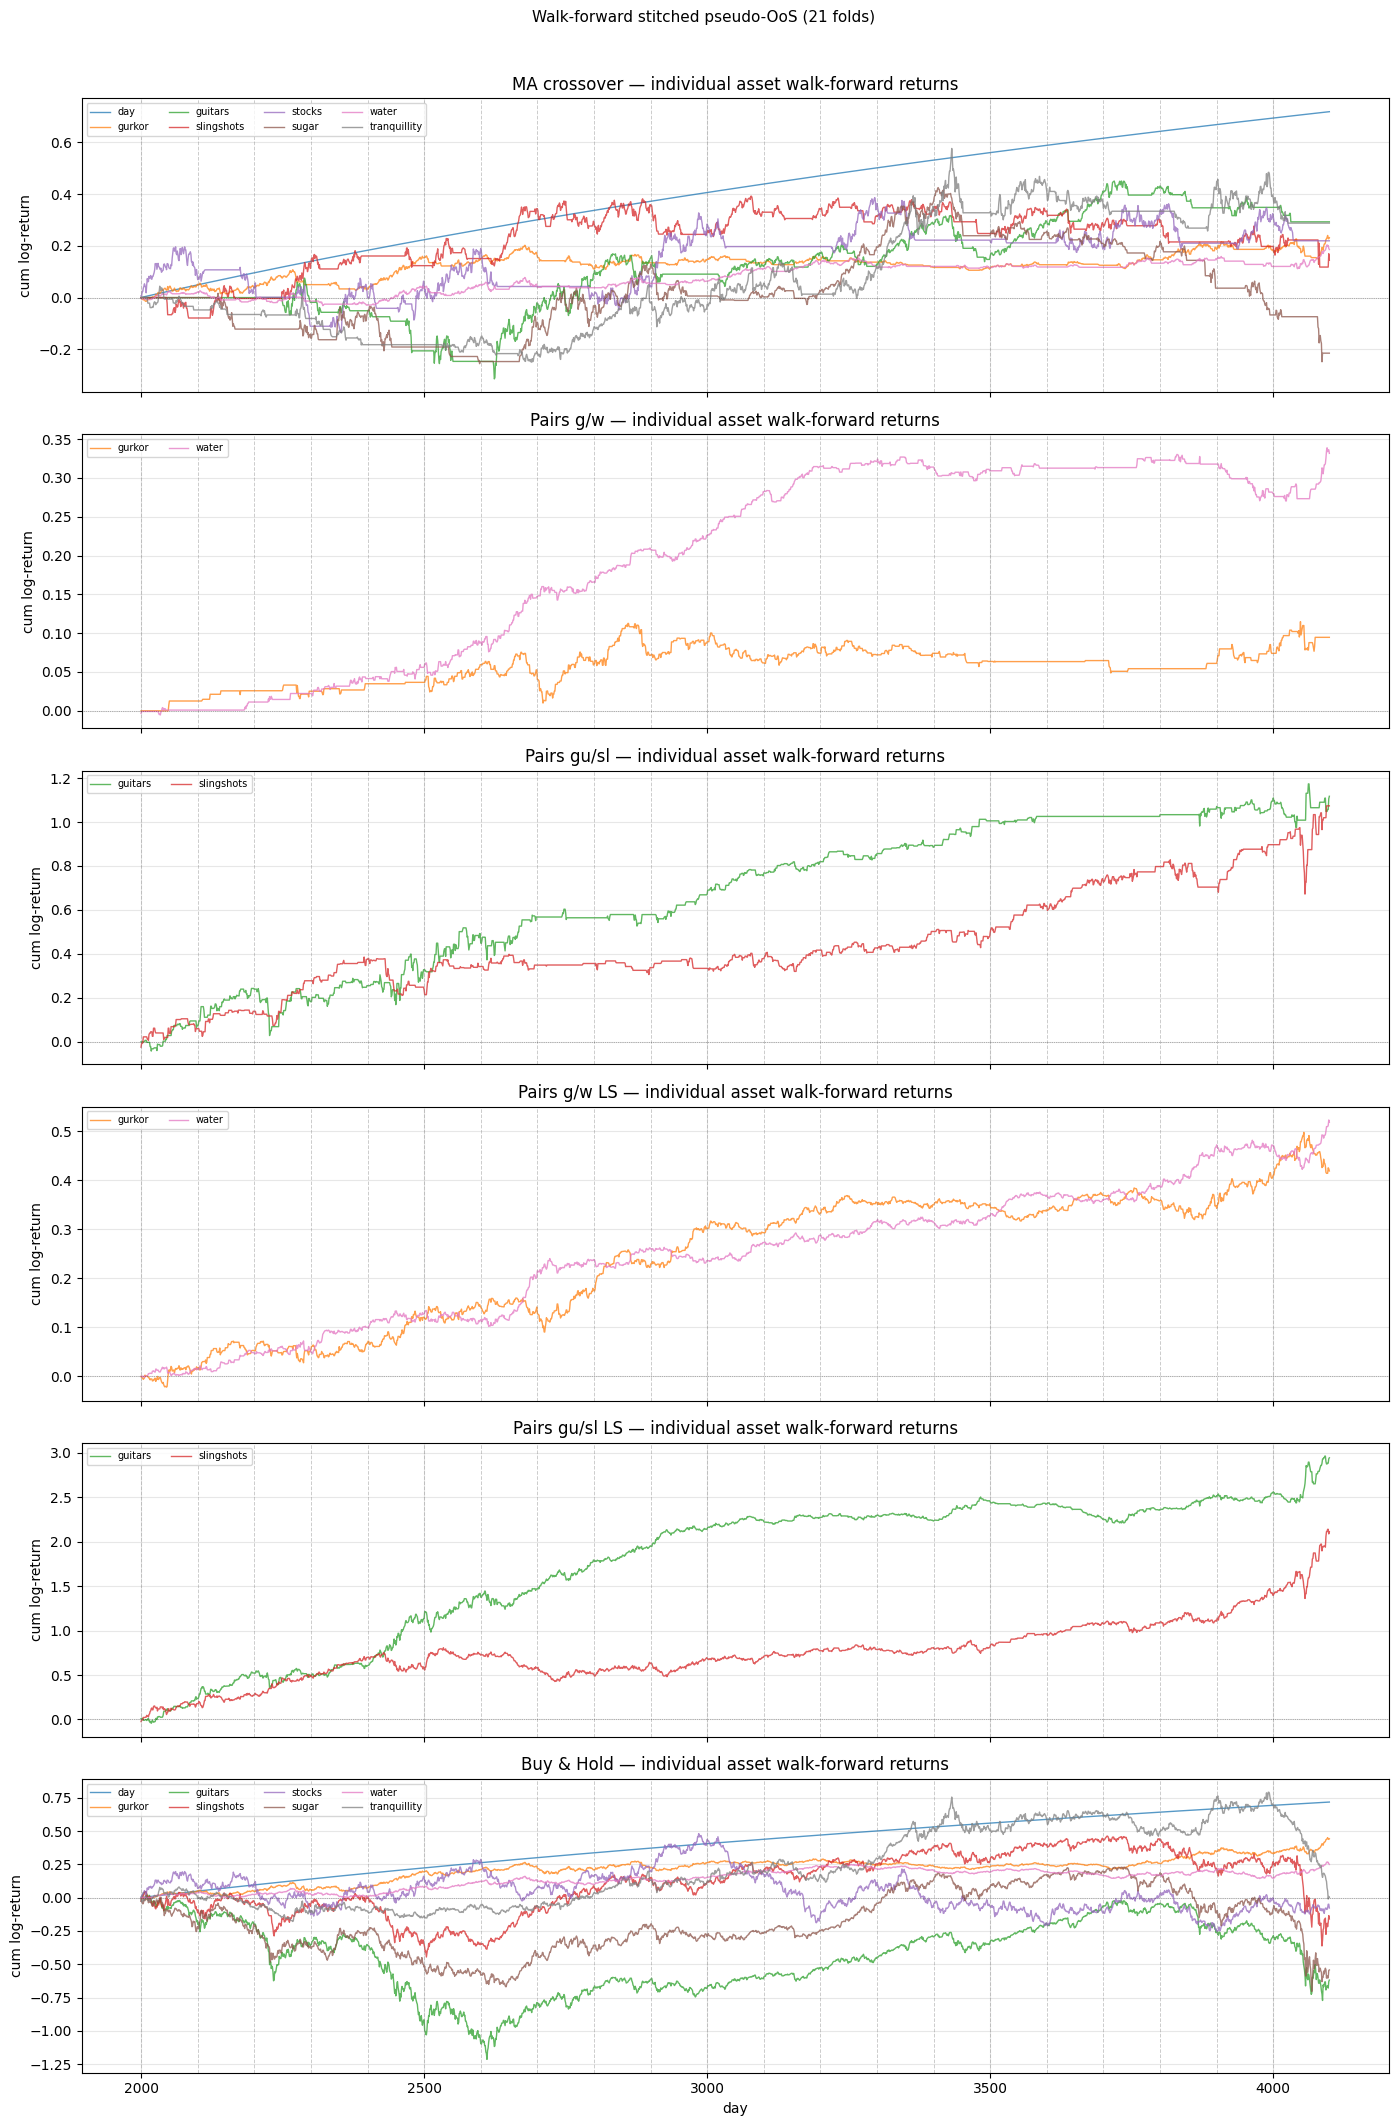

In [7]:
n_strats  = len(wf_specs)
fig, axes = plt.subplots(n_strats, 1, figsize=(14, 3.5 * n_strats), sharex=True)
for ax, (label, wf_ret, wf_sum) in zip(axes, wf_specs):
    for col in wf_ret.columns:
        ret = wf_ret[col]
        if (ret == 0).all():
            continue
        ax.plot(ret.cumsum().index, ret.cumsum().values, linewidth=1.0, alpha=0.75,
                color=asset_colors.get(col, "gray"), label=col)
    for _, row in wf_sum.iterrows():
        ax.axvline(row["OoS start"], color="gray", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.set_title(f"{label} — individual asset walk-forward returns")
    ax.set_ylabel("cum log-return")
    ax.legend(fontsize=7, ncol=4, loc="upper left")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
plt.suptitle(f"Walk-forward stitched pseudo-OoS ({WF_FOLDS} folds)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(output / "walk_forward.pdf", bbox_inches="tight")
plt.show()


In [8]:
def wf_asset_sharpe(ret_series, ann=365):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    v = sr.std() * np.sqrt(ann)
    return sr.mean() * ann / v if v > 0 else np.nan

def pos_folds_fraction(wf_ret, wf_sum, col, ann=365):
    count_pos, count_total = 0, 0
    for _, row in wf_sum.iterrows():
        fold_ret = wf_ret[col].loc[row["OoS start"]:row["OoS end"]].dropna()
        if (fold_ret == 0).all() or fold_ret.empty:
            continue
        v  = fold_ret.std() * np.sqrt(ann)
        sr = fold_ret.mean() * ann / v if v > 0 else np.nan
        count_total += 1
        if sr and sr > 0:
            count_pos += 1
    return count_pos / count_total if count_total > 0 else np.nan

rows = []
for label, wf_ret, wf_sum in wf_specs:
    for col in prices_is.columns:
        ret = wf_ret[col]
        if (ret == 0).all():
            continue
        m = backtest_metrics(ret, wf_bh[col])
        m["strategy"]     = label
        m["asset"]        = col
        m["pos_sr_folds"] = round(pos_folds_fraction(wf_ret, wf_sum, col), 2)
        rows.append(m)
wf_table = pd.DataFrame(rows).set_index(["strategy", "asset"])
print("Walk-forward performance metrics:")
display(wf_table)


Walk-forward performance metrics:


ann_return   cagr  excess_rf  ann_vol  sharpe  \
strategy       asset                                                         
MA crossover   day                12.48  13.29       9.48     0.14  91.385   
               gurkor              4.02   4.10       1.02     6.62   0.608   
               guitars             5.08   5.22       2.08    16.73   0.304   
               slingshots          2.51   2.54      -0.49    17.37   0.145   
               stocks              3.81   3.89       0.81    20.31   0.188   
               sugar              -3.73  -3.66      -6.73    17.48  -0.213   
               water               3.22   3.28       0.22     4.72   0.683   
               tranquillity        5.00   5.12       2.00    20.29   0.246   
Pairs g/w      gurkor              1.64   1.66      -1.36     4.09   0.402   
               water               5.76   5.93       2.76     3.54   1.627   
Pairs gu/sl    guitars            19.42  21.43      16.42    19.62   0.990   
               slingshots         18.66  20.52      15.66    18.43   1.013   
Pairs g/w LS   gurkor              7.29   7.56       4.29     6.73   1.083   
               water               9.02   9.44       6.02     5.08   1.775   
Pairs gu/sl LS guitars            51.18  66.83      48.18    27.45   1.865   
               slingshots         36.73  44.39      33.73    26.16   1.404   
Buy & Hold     day                12.48  13.29       9.48     0.14  91.385   
               gurkor              7.68   7.99       4.68     7.93   0.969   
               guitars           -10.76 -10.20     -13.76    31.64  -0.340   
               slingshots         -2.77  -2.73      -5.77    30.67  -0.090   
               stocks             -1.35  -1.34      -4.35    28.09  -0.048   
               sugar              -9.44  -9.00     -12.44    32.26  -0.292   
               water               4.34   4.44       1.34     5.93   0.733   
               tranquillity        0.03   0.03      -2.97    24.99   0.001   

                             max_dd  trades_yr  hold_days  bh_sharpe  \
strategy       asset                                                   
MA crossover   day             0.00        0.2     2100.0     91.385   
               gurkor         -9.21       20.3       11.3      0.969   
               guitars       -32.21       11.1       17.4     -0.340   
               slingshots    -23.95       15.5       12.4     -0.090   
               stocks        -28.15        2.4       80.2     -0.048   
               sugar         -48.96       19.5        8.9     -0.292   
               water          -5.60       14.4       14.7      0.733   
               tranquillity  -27.30       14.1       15.7      0.001   
Pairs g/w      gurkor         -6.33       50.1        1.9      0.969   
               water          -5.82       53.2        2.3      0.733   
Pairs gu/sl    guitars       -19.29       46.6        2.5     -0.340   
               slingshots    -26.09       48.8        2.6     -0.090   
Pairs g/w LS   gurkor         -8.02       74.7        3.3      0.969   
               water          -5.77       71.6        3.5      0.733   
Pairs gu/sl LS guitars       -25.30       54.2        5.0     -0.340   
               slingshots    -31.59       58.1        4.6     -0.090   
Buy & Hold     day             0.00        0.2     2100.0     91.385   
               gurkor         -8.39       19.5       17.7      0.969   
               guitars       -71.60        8.7       40.8     -0.340   
               slingshots    -56.18       15.3       22.8     -0.090   
               stocks        -52.00        0.5      699.3     -0.048   
               sugar         -60.65       26.9       12.4     -0.292   
               water         -10.16       13.9       25.1      0.733   
               tranquillity  -55.19       13.7       25.4      0.001   

                             excess_bh  pos_sr_folds  
strategy       asset                                  
MA crossover   da

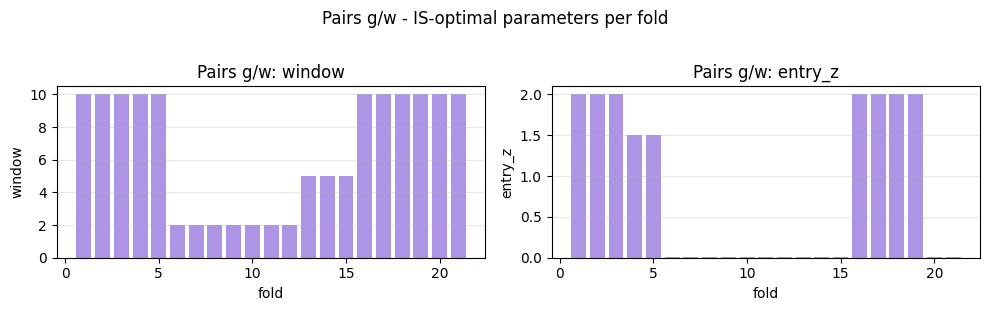

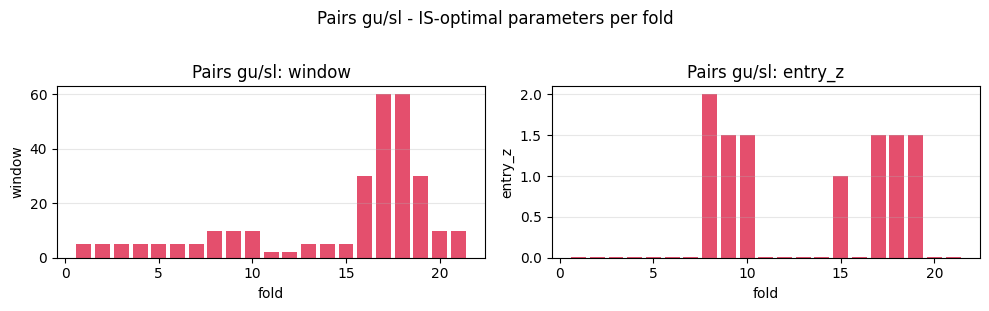

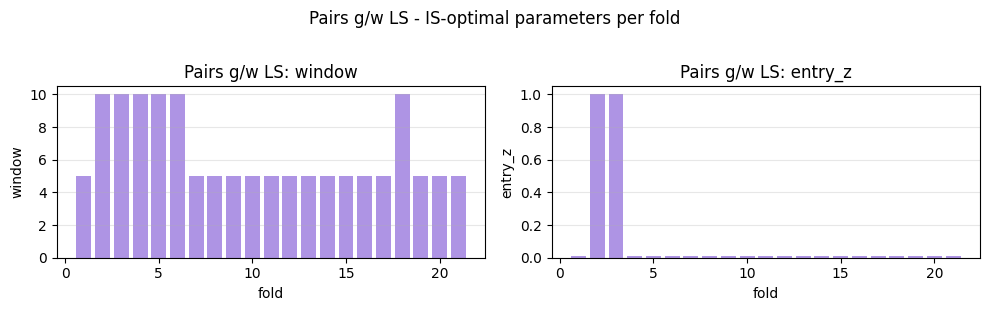

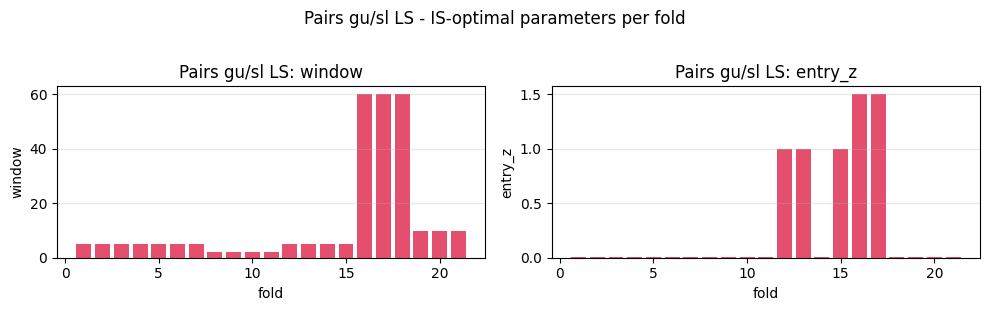

In [9]:
for name, par_df in [("Pairs g/w", wf_par_gw), ("Pairs gu/sl", wf_par_gusl),
                      ("Pairs g/w LS", wf_par_gw_ls), ("Pairs gu/sl LS", wf_par_gusl_ls)]:
    if par_df.empty or "window" not in par_df.columns:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    color = "mediumpurple" if "g/w" in name else "crimson"
    for ax, param in zip(axes, ["window", "entry_z"]):
        if param not in par_df.columns:
            continue
        ax.bar(par_df["fold"], par_df[param], color=color, alpha=0.75)
        ax.set_title(f"{name}: {param}"); ax.set_xlabel("fold"); ax.set_ylabel(param)
        ax.grid(True, alpha=0.3, axis="y")
    plt.suptitle(f"{name} - IS-optimal parameters per fold", y=1.02)
    plt.tight_layout()
    plt.savefig(output / f"param_stability_{name.replace(' ','_').replace('/','')}.pdf", bbox_inches="tight")
    plt.show()


In [10]:
N_BOOT = 2000

def bootstrap_sr_pvalue(ret_series, n_boot=N_BOOT, ann=365, random_state=42):
    rng  = np.random.default_rng(random_state)
    vals = ret_series.dropna().values
    if len(vals) < 10 or (vals == 0).all():
        return np.nan, np.nan, (np.nan, np.nan)
    n = len(vals)
    boot_srs = []
    for _ in range(n_boot):
        s   = rng.choice(vals, size=n, replace=True)
        vol = s.std() * np.sqrt(ann)
        boot_srs.append(s.mean() * ann / vol if vol > 0 else np.nan)
    boot_srs  = np.array(boot_srs)
    actual_sr = vals.mean() * ann / (vals.std() * np.sqrt(ann))
    lo, hi    = np.nanpercentile(boot_srs, [5, 95])
    p_val     = float(np.nanmean(boot_srs <= 0))
    return round(actual_sr, 3), round(p_val, 3), (round(lo, 3), round(hi, 3))

def bh_adjust(pv_matrix, active_mask):
    flat_idx = [(r, c) for r in pv_matrix.index for c in pv_matrix.columns
                if active_mask.loc[r, c] and not pd.isna(pv_matrix.loc[r, c])]
    if not flat_idx:
        return pv_matrix.copy()
    raw   = np.array([pv_matrix.loc[r, c] for r, c in flat_idx])
    m     = len(raw)
    order = np.argsort(raw)
    rank  = np.empty(m, dtype=int)
    rank[order] = np.arange(1, m + 1)
    adj = raw * m / rank
    for i in order[::-1]:
        neighbors = [adj[j] for j in range(m) if rank[j] > rank[i]]
        if neighbors:
            adj[i] = min(adj[i], min(neighbors))
    adj = np.minimum(adj, 1.0)
    pv_bh = pv_matrix.copy().astype(float) * np.nan
    for (r, c), v in zip(flat_idx, adj):
        pv_bh.loc[r, c] = round(float(v), 3)
    return pv_bh

strategy_labels = [l for l, _, _ in wf_specs]
sr_mat = pd.DataFrame(index=prices_is.columns, columns=strategy_labels, dtype=float)
pv_mat = pd.DataFrame(index=prices_is.columns, columns=strategy_labels, dtype=float)
for label, wf_ret, _ in wf_specs:
    for col in prices_is.columns:
        sr, pv, _ = bootstrap_sr_pvalue(wf_ret[col])
        sr_mat.loc[col, label] = sr
        pv_mat.loc[col, label] = pv

ever_active = pd.DataFrame({
    label: {col: bool((wf_ret[col] != 0).any()) for col in prices_is.columns}
    for label, wf_ret, _ in wf_specs
})
pv_bh = bh_adjust(pv_mat, ever_active)
print("Walk-forward Sharpe:"); display(sr_mat.round(2))
print("\nBH-adjusted p-values:"); display(pv_bh.round(3))


Walk-forward Sharpe:


,MA crossover,Pairs g/w,Pairs gu/sl,Pairs g/w LS,Pairs gu/sl LS,Buy & Hold
day,91.41,NaN,NaN,NaN,NaN,91.41
gurkor,0.61,0.40,NaN,1.08,NaN,0.97
guitars,0.30,NaN,0.99,NaN,1.86,-0.34
slingshots,0.14,NaN,1.01,NaN,1.40,-0.09
stocks,0.19,NaN,NaN,NaN,NaN,-0.05
sugar,-0.21,NaN,NaN,NaN,NaN,-0.29
water,0.68,1.63,NaN,1.78,NaN,0.73
tranquillity,0.25,NaN,NaN,NaN,NaN,0.00



BH-adjusted p-values:


,MA crossover,Pairs g/w,Pairs gu/sl,Pairs g/w LS,Pairs gu/sl LS,Buy & Hold
day,0.000,NaN,NaN,NaN,NaN,0.000
gurkor,0.127,0.303,NaN,0.014,NaN,0.021
guitars,0.360,NaN,0.022,NaN,0.0,0.792
slingshots,0.512,NaN,0.021,NaN,0.0,0.658
stocks,0.459,NaN,NaN,NaN,NaN,0.658
sugar,0.754,NaN,NaN,NaN,NaN,0.774
water,0.084,0.000,NaN,0.000,NaN,0.084
tranquillity,0.380,NaN,NaN,NaN,NaN,0.613


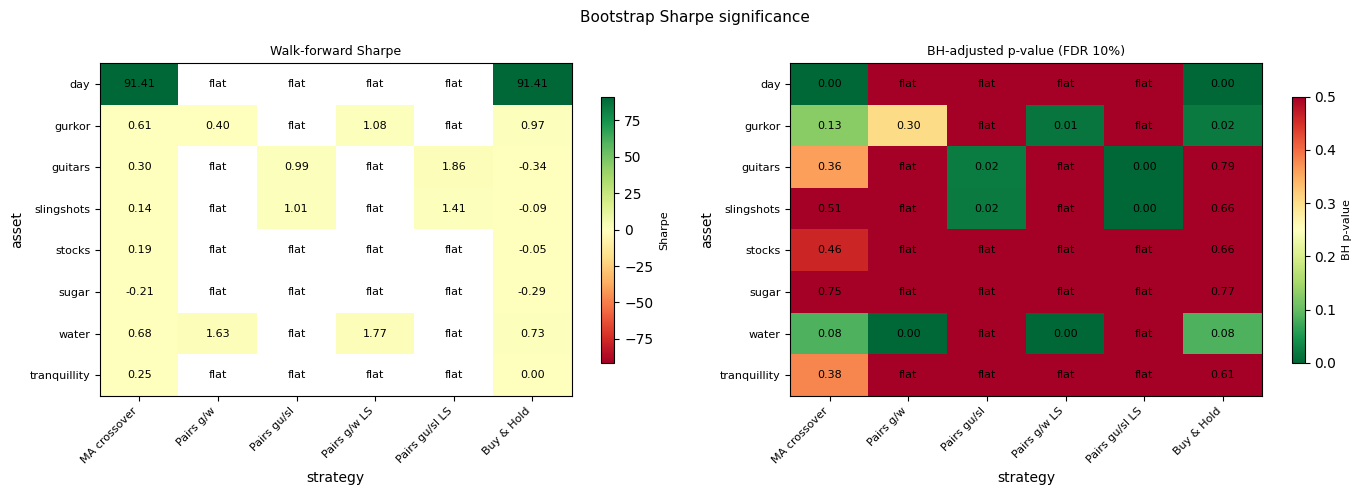

In [11]:
def make_annot(df, active_mask):
    annot = df.copy().astype(object)
    for col in df.columns:
        for idx in df.index:
            v = df.loc[idx, col]
            annot.loc[idx, col] = "flat" if not active_mask.loc[idx, col] else (
                f"{v:.2f}" if pd.notna(v) else "n/a")
    return annot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_heatmap(axes[0], sr_mat, annot_df=make_annot(sr_mat, ever_active),
             cmap="RdYlGn", center=0, title="Walk-forward Sharpe", cbar_label="Sharpe")
axes[0].set_ylabel("asset"); axes[0].set_xlabel("strategy")
bh_plot = pv_bh.fillna(0.5)
draw_heatmap(axes[1], bh_plot, annot_df=make_annot(pv_bh, ever_active),
             cmap="RdYlGn_r", center=0.25, vmin=0, vmax=0.5,
             title="BH-adjusted p-value (FDR 10%)", cbar_label="BH p-value")
axes[1].set_ylabel("asset"); axes[1].set_xlabel("strategy")
plt.suptitle("Bootstrap Sharpe significance", fontsize=11)
plt.tight_layout()
plt.savefig(output / "bootstrap_sharpe.pdf", bbox_inches="tight")
plt.show()


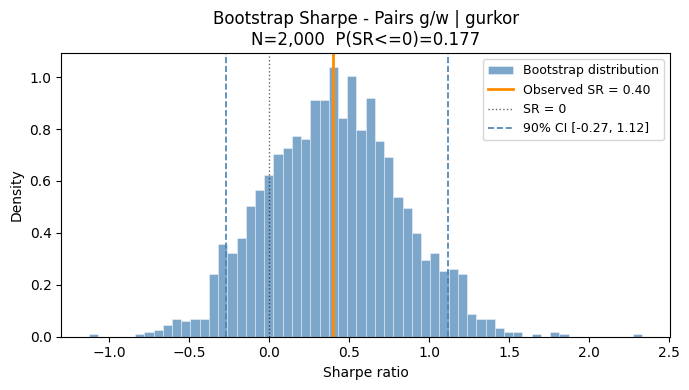

In [12]:
_STRATEGY = "Pairs g/w"
_ASSET    = "gurkor"
_wf_ret   = next(wf_ret for label, wf_ret, _ in wf_specs if label == _STRATEGY)
_vals     = _wf_ret[_ASSET].dropna().values
_rng = np.random.default_rng(42)
_n   = len(_vals)
_boot_srs = []
for _ in range(N_BOOT):
    _s   = _rng.choice(_vals, size=_n, replace=True)
    _vol = _s.std() * np.sqrt(365)
    _boot_srs.append(_s.mean() * 365 / _vol if _vol > 0 else np.nan)
_boot_srs  = np.array(_boot_srs)
_actual_sr = _vals.mean() * 365 / (_vals.std() * np.sqrt(365))
_lo, _hi   = np.nanpercentile(_boot_srs, [5, 95])
_p_val     = float(np.nanmean(_boot_srs <= 0))
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(_boot_srs[~np.isnan(_boot_srs)], bins=60, color="steelblue",
        alpha=0.7, edgecolor="white", linewidth=0.4, density=True, label="Bootstrap distribution")
ax.axvline(_actual_sr, color="darkorange", linewidth=2.0, label=f"Observed SR = {_actual_sr:.2f}")
ax.axvline(0, color="black", linewidth=1.0, linestyle=":", alpha=0.6, label="SR = 0")
ax.axvline(_lo, color="steelblue", linewidth=1.2, linestyle="--", label=f"90% CI [{_lo:.2f}, {_hi:.2f}]")
ax.axvline(_hi, color="steelblue", linewidth=1.2, linestyle="--")
ax.set_xlabel("Sharpe ratio"); ax.set_ylabel("Density")
ax.set_title(f"Bootstrap Sharpe - {_STRATEGY} | {_ASSET}\nN={N_BOOT:,}  P(SR<=0)={_p_val:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(output / "bootstrap_sr_pairs_gw_gurkor.pdf", bbox_inches="tight")
plt.show()


In [13]:
def evaluate_oos(signal_fn, param_grid, prices_is, prices_oos,
                 is_size=500, oos_step=100, per_asset=False, ann=365):
    all_prices = pd.concat([prices_is, prices_oos])
    oos_days   = prices_oos.index.tolist()
    chunks     = []
    orig_types = {k: type(v) for k, v in param_grid[0].items()} if param_grid else {}
    i = 0
    while i < len(oos_days):
        step_days  = oos_days[i:i + oos_step]
        cal_prices = all_prices[all_prices.index < step_days[0]].iloc[-is_size:]
        combined   = pd.concat([cal_prices, all_prices.loc[step_days]])
        if per_asset:
            best_p = per_asset_grid_search(cal_prices, signal_fn, param_grid)
            sig    = build_per_asset_signal(combined, signal_fn, best_p)
        elif param_grid:
            g      = grid_search(cal_prices, signal_fn, param_grid)
            best_p = {k: orig_types[k](g.loc[g["sharpe"].idxmax(), k]) for k in orig_types}
            sig    = signal_fn(combined, **best_p)
        else:
            sig = signal_fn(combined)
        chunks.append(apply_signal(sig, combined)["returns"].loc[step_days])
        i += oos_step
    return pd.concat(chunks)

print("Evaluating on true OoS...")
oos_ma      = evaluate_oos(ma_crossover_signal, MA_PARAM_GRID,    prices_is, prices_oos, per_asset=True)
oos_gw      = evaluate_oos(gw_signal,           PAIRS_PARAM_GRID, prices_is, prices_oos)
oos_gusl    = evaluate_oos(gusl_signal,         PAIRS_PARAM_GRID, prices_is, prices_oos)
oos_gw_ls   = evaluate_oos(gw_ls_signal,        PAIRS_PARAM_GRID, prices_is, prices_oos)
oos_gusl_ls = evaluate_oos(gusl_ls_signal,      PAIRS_PARAM_GRID, prices_is, prices_oos)
oos_bh      = evaluate_oos(buy_and_hold_signal, [],               prices_is, prices_oos)
print("Done.")
oos_specs = [
    ("MA crossover",   oos_ma), ("Pairs g/w",      oos_gw),
    ("Pairs gu/sl",    oos_gusl), ("Pairs g/w LS",   oos_gw_ls),
    ("Pairs gu/sl LS", oos_gusl_ls), ("Buy & Hold",     oos_bh),
]


Evaluating on true OoS...
Done.


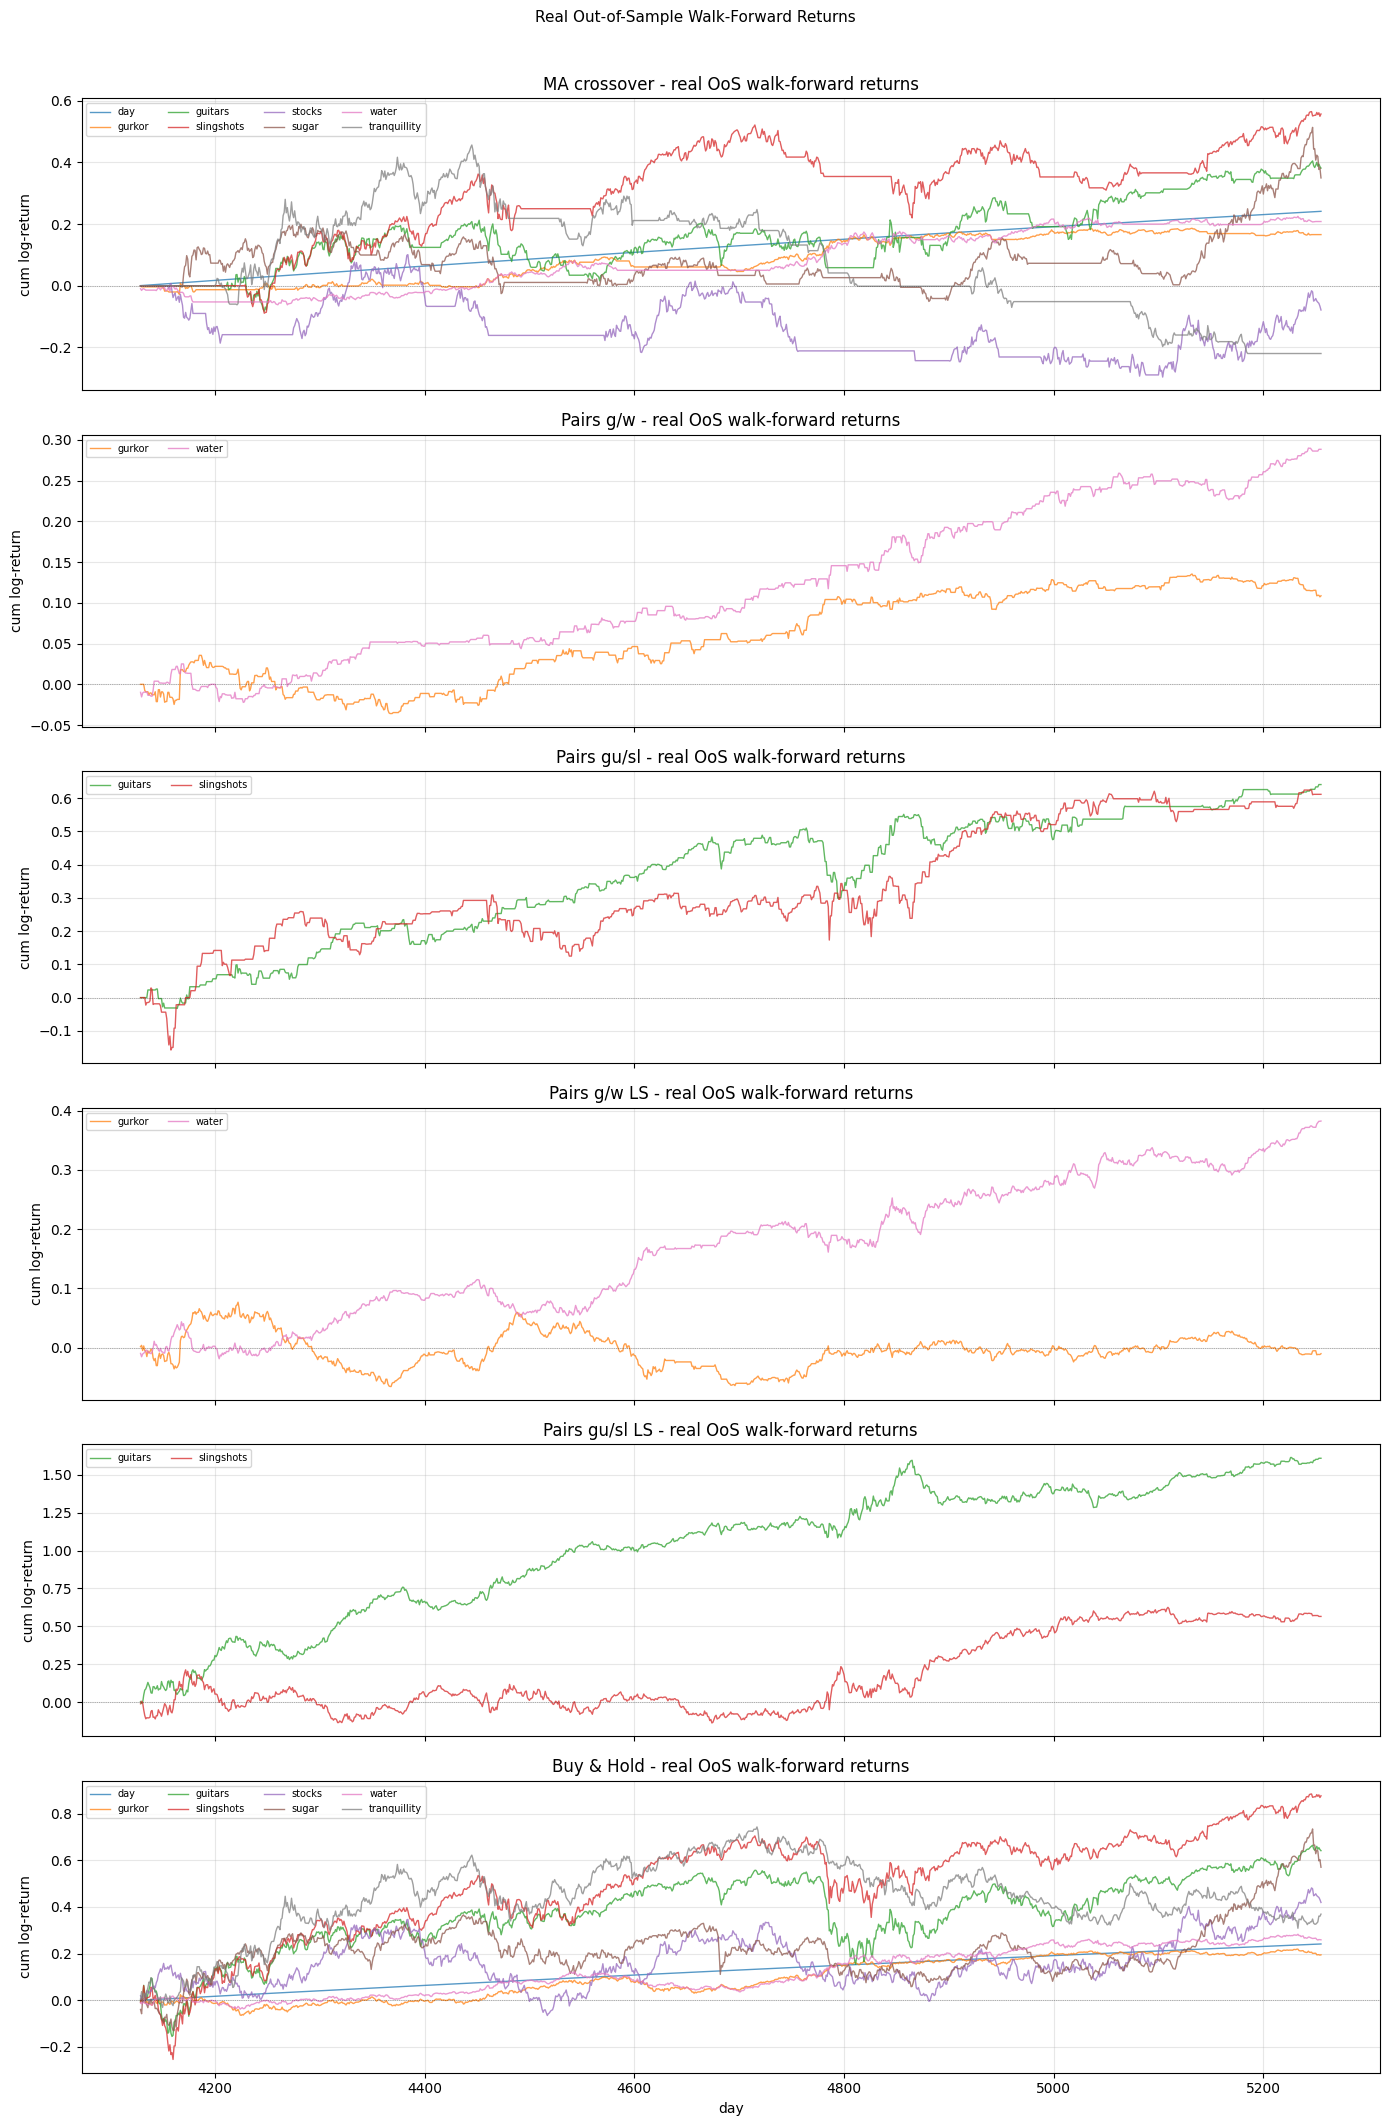

In [14]:
fig, axes = plt.subplots(len(oos_specs), 1, figsize=(14, 3.5 * len(oos_specs)), sharex=True)
for ax, (label, oos_ret) in zip(axes, oos_specs):
    for col in oos_ret.columns:
        ret = oos_ret[col]
        if (ret == 0).all():
            continue
        ax.plot(ret.cumsum().index, ret.cumsum().values, linewidth=1.0, alpha=0.75,
                color=asset_colors.get(col, "gray"), label=col)
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.set_title(f"{label} - real OoS walk-forward returns")
    ax.set_ylabel("cum log-return")
    ax.legend(fontsize=7, ncol=4, loc="upper left")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
plt.suptitle("Real Out-of-Sample Walk-Forward Returns", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(output / "oos_returns.pdf", bbox_inches="tight")
plt.show()


In [15]:
oos_rows = []
for label, oos_ret in oos_specs:
    for col in prices_is.columns:
        ret = oos_ret[col]
        if (ret == 0).all():
            continue
        m = backtest_metrics(ret, oos_bh[col])
        m["strategy"] = label; m["asset"] = col
        oos_rows.append(m)
oos_table = pd.DataFrame(oos_rows).set_index(["strategy", "asset"])
print("True OoS performance:"); display(oos_table)


True OoS performance:


ann_return   cagr  excess_rf  ann_vol   sharpe  \
strategy       asset                                                          
MA crossover   day                 7.82   8.13       4.82     0.03  273.844   
               gurkor              5.37   5.52       2.37     5.85    0.917   
               guitars            12.36  13.16       9.36    19.76    0.625   
               slingshots         18.05  19.78      15.05    21.07    0.856   
               stocks             -2.55  -2.52      -5.55    22.09   -0.116   
               sugar              11.33  11.99       8.33    19.00    0.596   
               water               6.75   6.98       3.75     6.77    0.996   
               tranquillity       -7.13  -6.88     -10.13    21.78   -0.327   
Pairs g/w      gurkor              3.52   3.58       0.52     5.41    0.651   
               water               9.34   9.79       6.34     5.33    1.753   
Pairs gu/sl    guitars            20.74  23.05      17.74    15.58    1.332   
               slingshots         19.79  21.89      16.79    22.66    0.873   
Pairs g/w LS   gurkor             -0.33  -0.33      -3.33     7.27   -0.046   
               water              12.38  13.18       9.38     7.41    1.671   
Pairs gu/sl LS guitars            52.08  68.34      49.08    27.74    1.878   
               slingshots         18.31  20.10      15.31    31.46    0.582   
Buy & Hold     day                 7.82   8.13       4.82     0.03  273.844   
               gurkor              6.31   6.51       3.31     7.64    0.826   
               guitars            20.77  23.08      17.77    28.02    0.741   
               slingshots         28.39  32.82      25.39    31.74    0.894   
               stocks             13.58  14.54      10.58    28.72    0.473   
               sugar              18.47  20.29      15.47    26.37    0.700   
               water               8.39   8.76       5.39     7.80    1.076   
               tranquillity       11.96  12.70       8.96    28.98    0.413   

                             max_dd  trades_yr  hold_days  bh_sharpe  \
strategy       asset                                                   
MA crossover   day             0.00        0.3     1127.0    273.844   
               gurkor         -4.62       17.2       13.7      0.826   
               guitars       -17.89        8.7       28.7      0.741   
               slingshots    -26.03       12.3       20.0      0.894   
               stocks        -32.78        4.2       49.6      0.473   
               sugar         -22.16       23.0        9.1      0.700   
               water          -5.98       10.7       23.3      1.076   
               tranquillity  -49.17        8.7       20.9      0.413   
Pairs g/w      gurkor         -6.89       77.7        1.9      0.826   
               water          -4.61       76.4        1.9      1.076   
Pairs gu/sl    guitars       -18.99       71.9        2.0      0.741   
               slingshots    -17.03       72.9        2.0      0.894   
Pairs g/w LS   gurkor        -13.26       32.4        9.6      0.826   
               water          -6.13       27.5       11.4      1.076   
Pairs gu/sl LS guitars       -26.75       13.6       25.5      0.741   
               slingshots    -29.55       22.7       14.9      0.894   
Buy & Hold     day             0.00        0.3     1127.0    273.844   
               gurkor         -8.48       18.1       19.1      0.826   
               guitars       -33.16        5.5       65.1      0.741   
               slingshots    -29.49       14.9       23.5      0.894   
               stocks        -33.76        0.3     1127.0      0.473   
               sugar         -26.49       28.8       11.5      0.700   
               water          -8.34       11.0       31.9      1.076   
               tranquillity  -35.23       11.0       31.9      0.413   

                             excess_bh  
strategy       asset                    
MA crossover   day 

In [16]:
def mvp_weights(returns_df, long_only=True):
    cov = returns_df.dropna().cov().values
    n   = cov.shape[0]
    if long_only:
        res = minimize(lambda w: w @ cov @ w, x0=np.ones(n) / n,
                       method="SLSQP", bounds=[(0, 1)] * n,
                       constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
        return res.x if res.success else np.ones(n) / n
    ones    = np.ones(n)
    cov_inv = np.linalg.inv(cov)
    return cov_inv @ ones / (ones @ cov_inv @ ones)

def walk_forward_portfolio(prices, weight_fn, rebal_step=100, cal_window=500):
    log_ret = np.log(prices).diff()
    rets, ws = [], []
    for i in range(cal_window, len(prices), rebal_step):
        cal = log_ret.iloc[i - cal_window:i].dropna()
        w   = weight_fn(cal)
        rets.append((log_ret.iloc[i:i + rebal_step] * w).sum(axis=1))
        ws.append(w)
    return pd.concat(rets), np.array(ws)

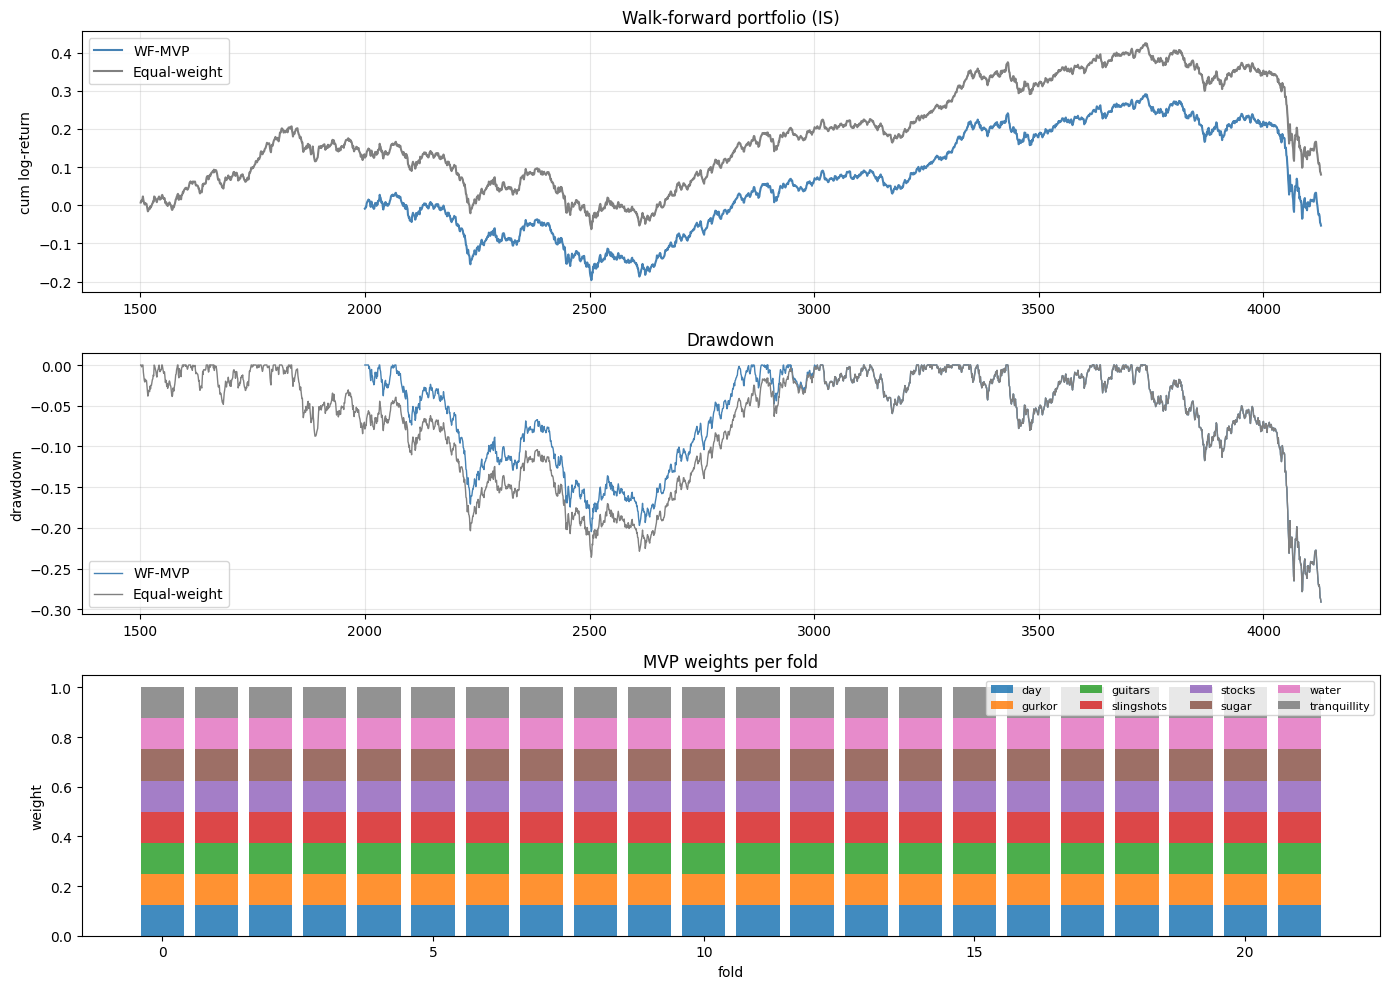

IS Sharpe ratios:
  MVP              Sharpe = -0.090  Ann.vol = 10.10%
  Equal-weight     Sharpe = 0.113  Ann.vol = 9.87%


In [17]:
wf_mvp_ret, wf_mvp_w = walk_forward_portfolio(prices_is, mvp_weights)
wf_ew_ret             = np.log(prices_is).diff().dropna().mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
ax = axes[0]
for name, ret, color in [("WF-MVP", wf_mvp_ret, "steelblue"),
                          ("Equal-weight", wf_ew_ret, "gray")]:
    ax.plot(ret.cumsum().index, ret.cumsum().values, color=color, lw=1.5, label=name)
ax.set_title("Walk-forward portfolio (IS)"); ax.set_ylabel("cum log-return")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, ret, color in [("WF-MVP", wf_mvp_ret, "steelblue"),
                          ("Equal-weight", wf_ew_ret, "gray")]:
    eq = np.exp(ret.cumsum()); dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, color=color, lw=1.0, label=name)
ax.set_title("Drawdown"); ax.set_ylabel("drawdown"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
bottom = np.zeros(len(wf_mvp_w))
for j, col in enumerate(prices_is.columns):
    w_col = wf_mvp_w[:, j]
    ax.bar(range(len(wf_mvp_w)), w_col, bottom=bottom, label=col, color=asset_colors[col], alpha=0.85)
    bottom += w_col
ax.set_title("MVP weights per fold"); ax.set_ylabel("weight"); ax.set_xlabel("fold")
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.savefig(output / "portfolio_is.pdf", bbox_inches="tight")
plt.show()

print("IS Sharpe ratios:")
for name, ret in [("MVP", wf_mvp_ret), ("Equal-weight", wf_ew_ret)]:
    v = ret.std() * np.sqrt(ANN)
    print(f"  {name:15s}  Sharpe = {ret.mean()*ANN/v:.3f}  Ann.vol = {v*100:.2f}%")


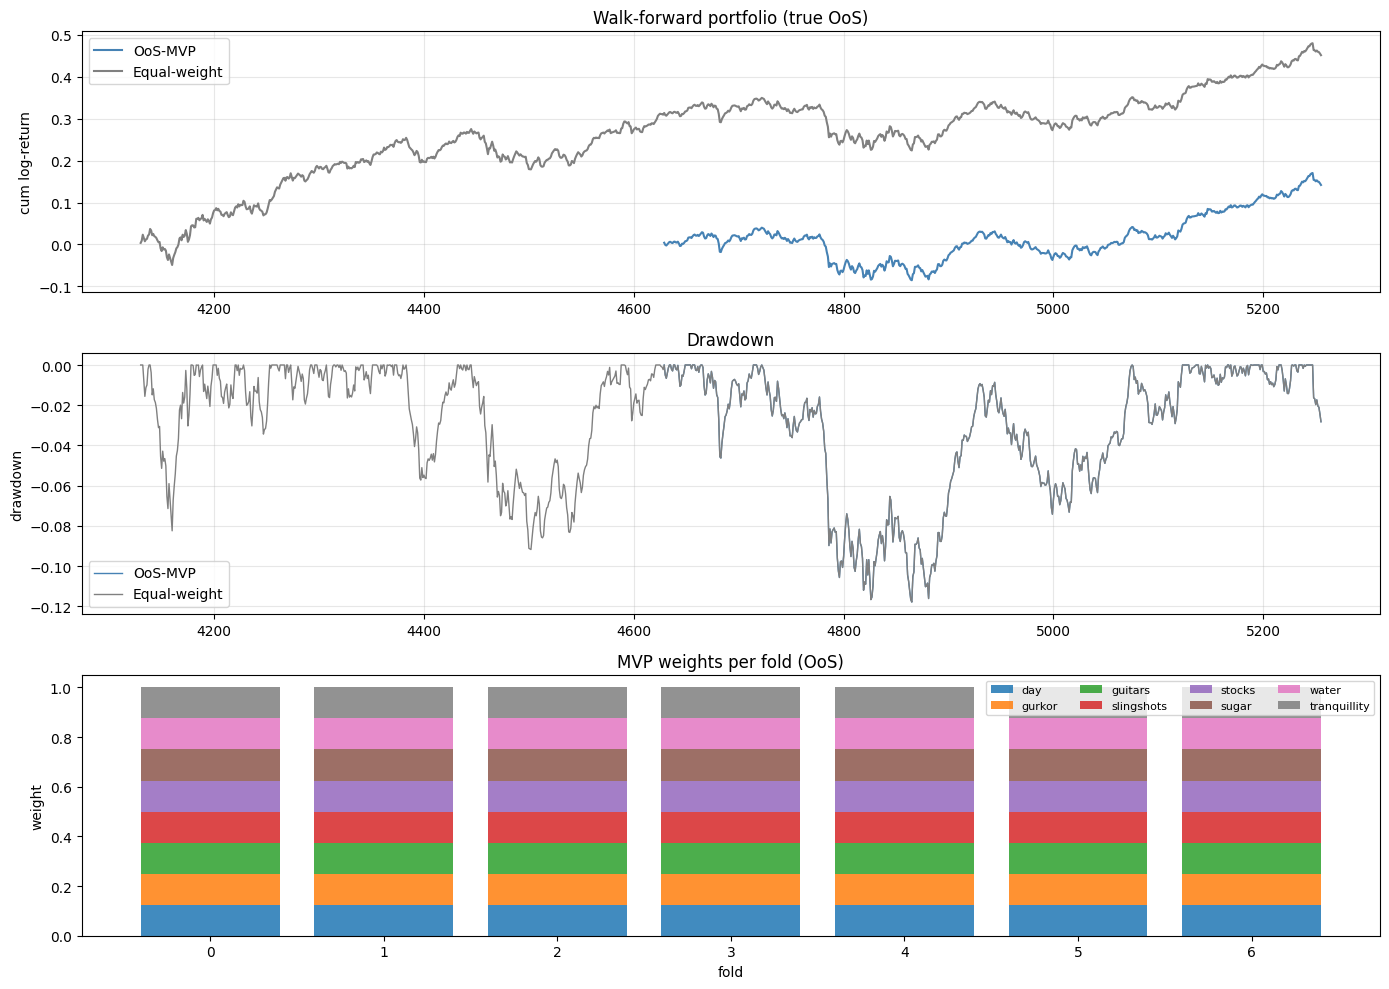

True OoS Sharpe ratios:
  MVP              Sharpe = 0.895  Ann.vol = 9.23%
  Equal-weight     Sharpe = 1.447  Ann.vol = 10.12%


In [18]:
oos_mvp_ret, oos_mvp_w = walk_forward_portfolio(prices_oos, mvp_weights)
oos_ew_ret              = np.log(prices_oos).diff().dropna().mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
ax = axes[0]
for name, ret, color in [("OoS-MVP", oos_mvp_ret, "steelblue"),
                          ("Equal-weight", oos_ew_ret, "gray")]:
    ax.plot(ret.cumsum().index, ret.cumsum().values, color=color, lw=1.5, label=name)
ax.set_title("Walk-forward portfolio (true OoS)"); ax.set_ylabel("cum log-return")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, ret, color in [("OoS-MVP", oos_mvp_ret, "steelblue"),
                          ("Equal-weight", oos_ew_ret, "gray")]:
    eq = np.exp(ret.cumsum()); dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, color=color, lw=1.0, label=name)
ax.set_title("Drawdown"); ax.set_ylabel("drawdown"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
bottom = np.zeros(len(oos_mvp_w))
for j, col in enumerate(prices_oos.columns):
    w_col = oos_mvp_w[:, j]
    ax.bar(range(len(oos_mvp_w)), w_col, bottom=bottom, label=col, color=asset_colors[col], alpha=0.85)
    bottom += w_col
ax.set_title("MVP weights per fold (OoS)"); ax.set_ylabel("weight"); ax.set_xlabel("fold")
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.savefig(output / "portfolio_oos.pdf", bbox_inches="tight")
plt.show()

print("True OoS Sharpe ratios:")
for name, ret in [("MVP", oos_mvp_ret), ("Equal-weight", oos_ew_ret)]:
    v = ret.std() * np.sqrt(ANN)
    print(f"  {name:15s}  Sharpe = {ret.mean()*ANN/v:.3f}  Ann.vol = {v*100:.2f}%")
